<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 4 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">Regresión, ¿qué línea de crédito darle a cada bodega?</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥🐥🐥▫️▫️▫️ · clase 4 de 7

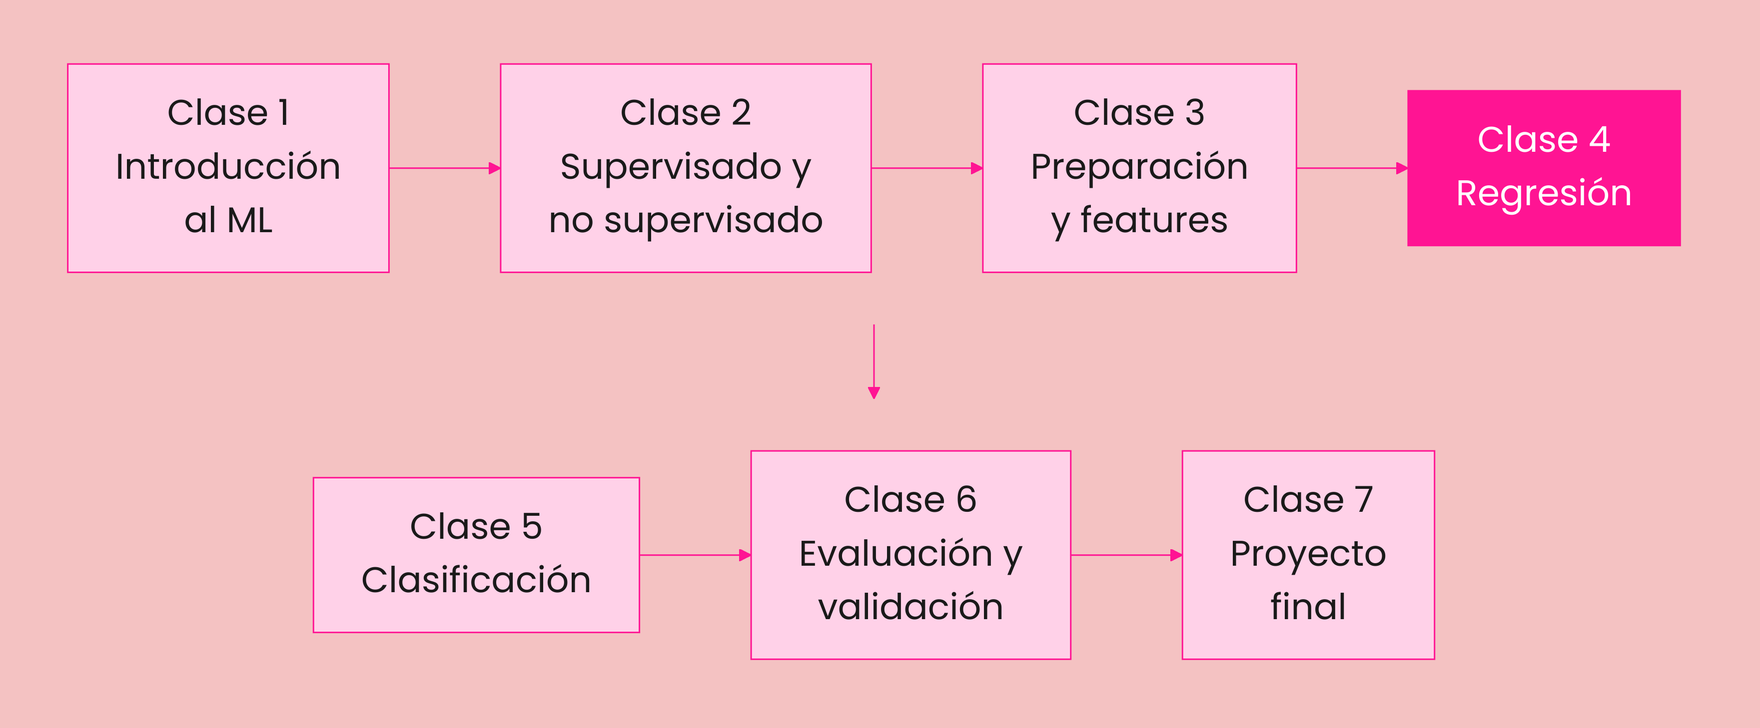


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 3, el 70% del trabajo real, limpiar las solicitudes de crédito, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 3 de la playlist antes de continuar.


In [ ]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿Por qué se escala DESPUÉS de partir train y test?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_0" value="0"> Porque es más rápido</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_0" value="1"> Para no filtrar información del test al entrenamiento</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_0" value="2"> Porque scikit-learn lo exige</label><div id="qin4_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Qué hace el encoding con las categorías?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_1" value="0"> Las elimina del dataset</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_1" value="1"> Las convierte en números</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin4_1" value="2"> Las ordena alfabéticamente</label><div id="qin4_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "piensa en el diagrama de la trampa del data leakage"], [1, "los modelos solo comen n\u00fameros"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin4_"+i+"\']:checked");
        var fb=document.getElementById("qin4_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Aplicar la receta universal de scikit-learn, crear, entrenar, predecir y evaluar.
- Leer las tres métricas de la regresión y explicarlas en soles, no en jerga.
- Enfrentar la lineal contra el bosque aleatorio y decidir qué línea de crédito recibe cada bodega.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"Cada analista asigna líneas de crédito a su criterio y hay peleas todas las semanas. Necesito un número objetivo por bodega según las características de su local."</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 04</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Regresión con scikit-learn</h1>
  <div style="font-size: 18px; opacity: .96;">Predecir números y entender qué mueve la aguja</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Aplicar la receta universal de scikit-learn, fit, predict, score</li>
<li>Entrenar una regresión lineal y leer sus coeficientes</li>
<li>Medir con MAE, RMSE y R² sabiendo qué dice cada una</li>
<li>Comparar la lineal contra un bosque aleatorio de regresión</li>
<li>Detectar residuos con patrón, la señal de que falta algo</li></ul>
</div>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

## 1. La misión, predecir el precio de linea_credito en Lima

PolliCreditos quiere estimar el linea_credito mensual de una bodega a partir de sus características. El target es un número, terreno de la regresión.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 400

df = pd.DataFrame({
    "metros": np.random.uniform(35, 160, n).round(0),
    "trabajadores": np.random.randint(1, 5, n),
    "antiguedad": np.random.randint(0, 40, n),
    "distancia_centro_km": np.random.uniform(0.5, 25, n).round(1),
})

# Precio con lógica de mercado más ruido realista
df["linea_credito"] = (
    600
    + 14 * df["metros"]
    + 180 * df["trabajadores"]
    - 12 * df["antiguedad"]
    - 28 * df["distancia_centro_km"]
    + np.random.normal(0, 180, n)
).round(0)

print(df.describe().round(1))
df.head()

## 2. La receta universal de scikit-learn

Todos los modelos de la librería se usan igual. Apréndete esta coreografía de cuatro pasos y ya sabes usar cientos de modelos.

```text
1. Separar     train_test_split
2. Crear       modelo = Modelo()
3. Entrenar    modelo.fit(X_train, y_train)
4. Evaluar     modelo.predict(X_test) y métricas
```

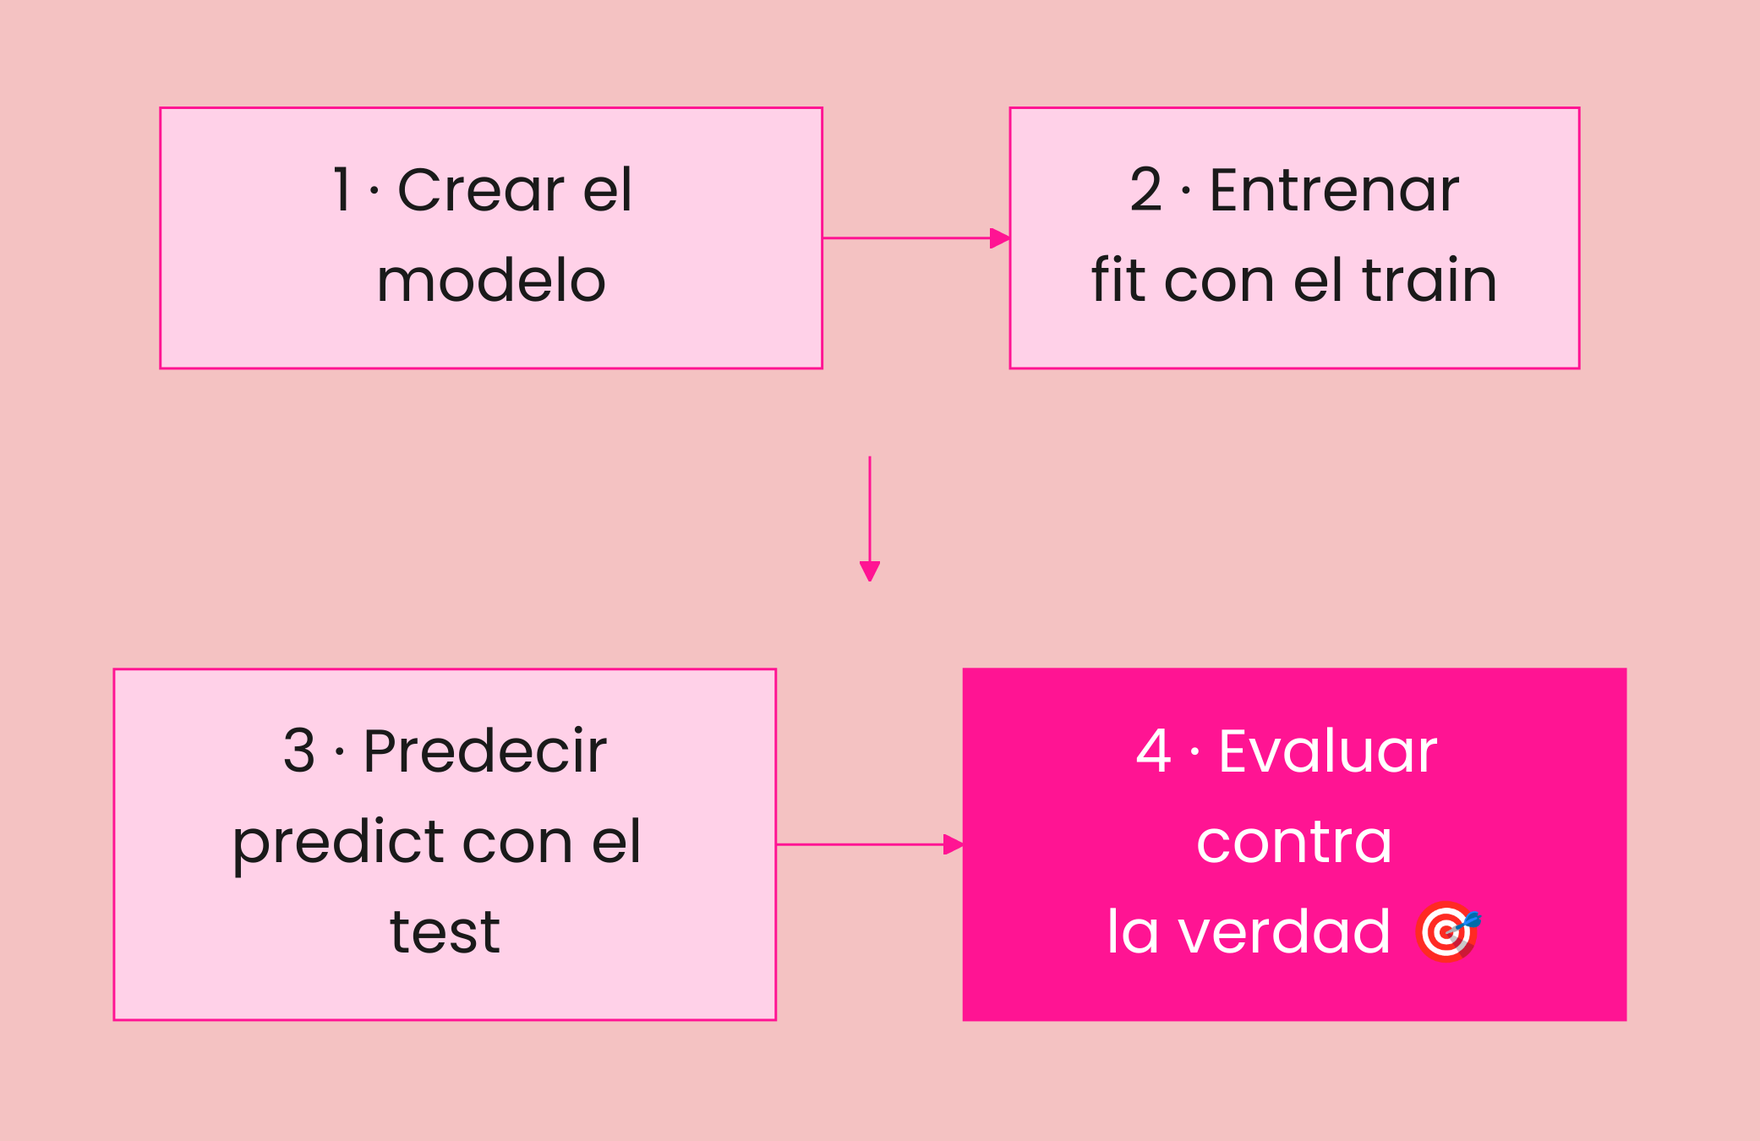

*La receta es siempre la misma, crear el modelo, entrenarlo con train, predecir en test y evaluar contra la verdad.*


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["metros", "trabajadores", "antiguedad", "distancia_centro_km"]]
y = df["linea_credito"]

X_train, X_test, y_train, y_test = ____(X, y, test_size=0.3, random_state=42)

lineal = ____()
lineal.____(X_train, y_train)
predicciones = lineal.____(X_test)

print("Primeras 5 predicciones contra la realidad,")
comparacion = pd.DataFrame({"real": y_test.values[:5], "predicho": predicciones[:5].round(0)})
comparacion["error"] = (comparacion["real"] - comparacion["predicho"]).round(0)
print(comparacion)

## 3. Leyendo la mente del modelo, los coeficientes

In [ ]:
coefs = pd.Series(lineal.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(f"Precio base (intercepto), S/ {lineal.intercept_:,.0f}\n")
for feature, coef in coefs.items():
    direccion = "sube" if coef > 0 else "baja"
    print(f"Cada unidad extra de {feature:22s} {direccion} el linea_credito en S/ {abs(coef):,.0f}")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
La regresión lineal es el modelo más interpretable que existe, cada coeficiente es una historia de negocio. El metro cuadrado suma, la antigüedad y la distancia restan. Esta transparencia es la razón por la que bancos y aseguradoras la siguen usando, pueden explicar cada predicción a un regulador.
</div>


## 4. Las tres métricas de la regresión

### 🧮 La matemática detrás · Cálculo diferencial, minimizar el error

$J(\beta) = \sum_i (y_i - \hat{y}_i)^2 \qquad \dfrac{\partial J}{\partial \beta} = 0$

**Lectura en palabras,** el error total es una montaña, la derivada te dice hacia dónde baja, y el mínimo de la montaña es tu mejor recta.

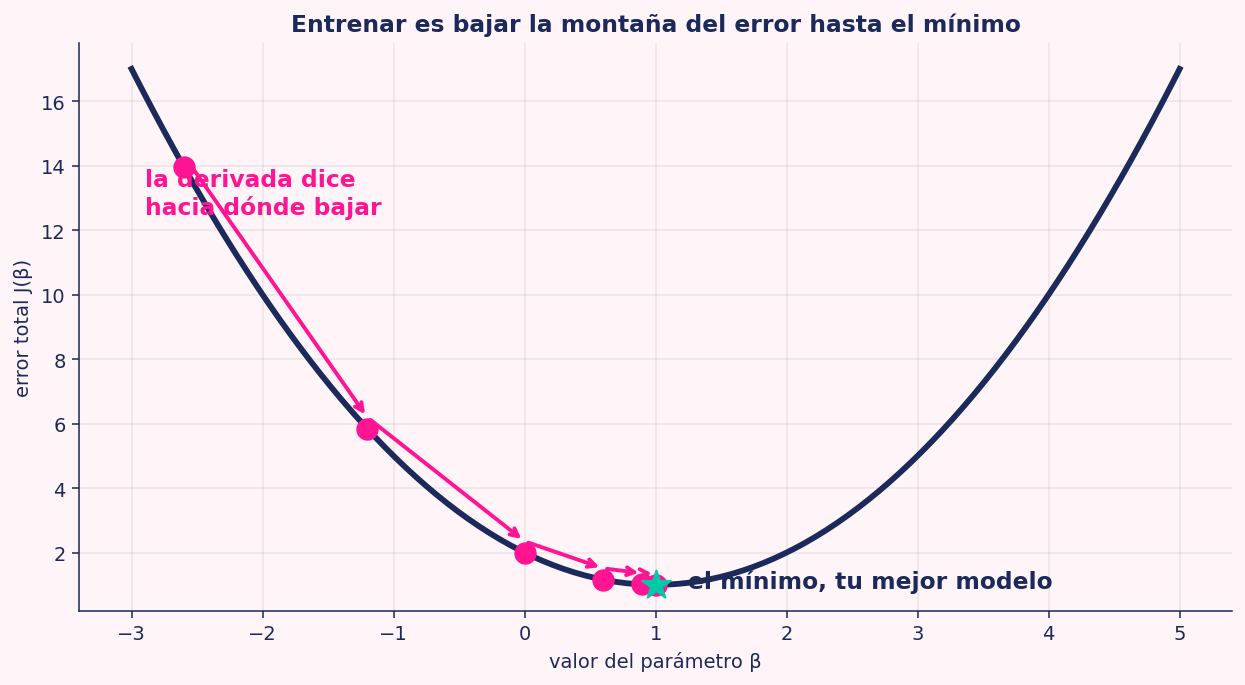

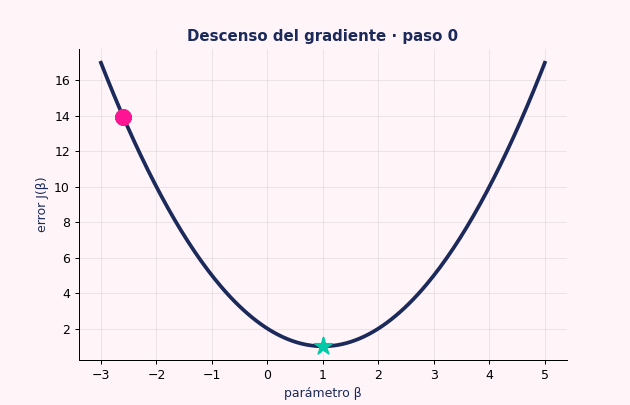

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> Esto es literalmente lo que hace fit por dentro, y el gradiente descendente que mueve a todo el deep learning es esta misma idea repetida millones de veces.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = ____(y_test, predicciones)
rmse = np.sqrt(____(y_test, predicciones))
r2 = ____(y_test, predicciones)

print(f"MAE,  S/ {mae:,.0f}   → en promedio nos equivocamos por este monto")
print(f"RMSE, S/ {rmse:,.0f}   → parecido al MAE pero castiga más los errores grandes")
print(f"R²,   {r2:.3f}    → el modelo explica el {r2:.1%} de la variación del precio")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Cuál métrica le cuento al cliente?</b><br>
El MAE, porque habla el idioma del negocio, nos equivocamos en promedio S/ 150 por bodega se entiende de una. El RMSE sirve para comparar modelos cuando los errores grandes duelen más. El R² resume qué tanto del fenómeno capturamos, pero un R² alto no garantiza errores chicos en soles.
</div>


## 5. El torneo, lineal contra bosque aleatorio

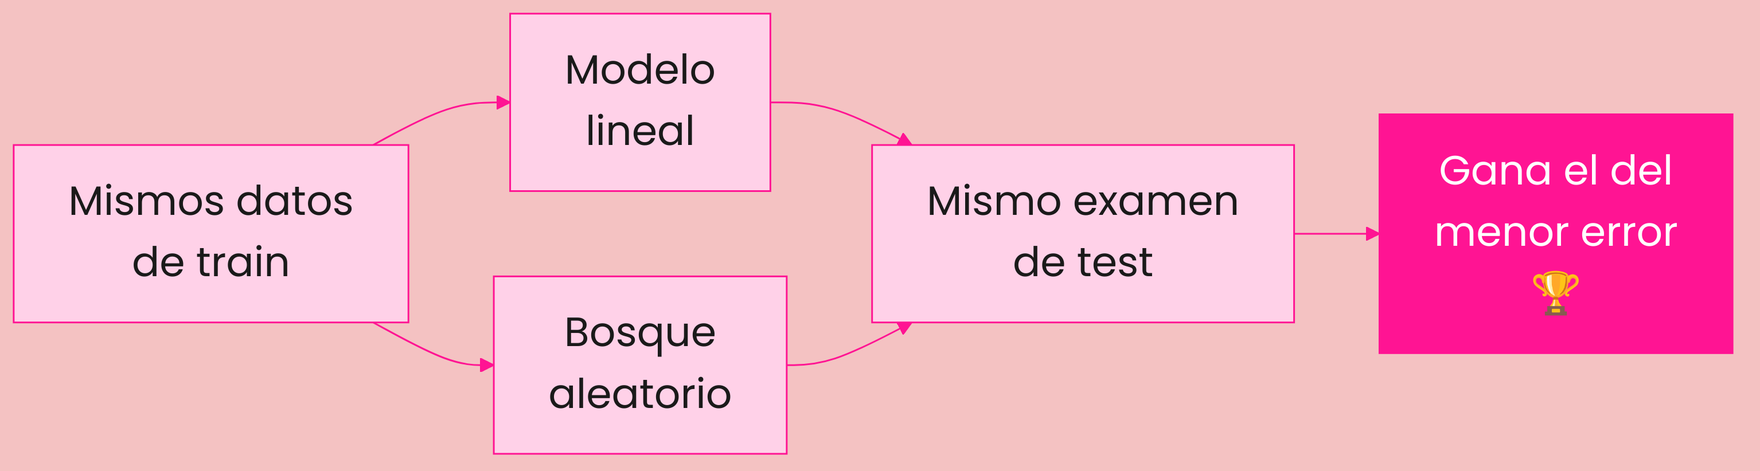

*Mismos datos y mismo examen para todos, gana el modelo con menor error.*


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.ensemble import RandomForestRegressor

bosque = ____(n_estimators=200, random_state=42)
bosque.____(X_train, y_train)
pred_bosque = bosque.____(X_test)

resultados = pd.DataFrame({
    "modelo": ["Regresión lineal", "Random Forest"],
    "MAE": [mae, ____(y_test, pred_bosque)],
    "RMSE": [rmse, np.sqrt(mean_squared_error(y_test, pred_bosque))],
    "R2": [r2, r2_score(y_test, pred_bosque)],
}).round(3)
print(resultados.to_string(index=False))
print("\nLa relación de fondo es lineal, por eso la lineal compite de igual a igual,")
print("el bosque brilla cuando hay curvas e interacciones que la lineal no puede dibujar")

## 6. El gráfico de la verdad, predicho contra real

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, nombre in [(axes[0], predicciones, "Lineal"), (axes[1], pred_bosque, "Random Forest")]:
    ax.scatter(y_test, preds, alpha=0.6, s=35, color=YERA[0], edgecolor="white")
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "--", color=YERA[5], linewidth=2, label="Predicción perfecta")
    ax.set_title(f"{nombre}, predicho contra real")
    ax.set_xlabel("Línea de crédito real (S/)")
    ax.set_ylabel("Línea de crédito predicho (S/)")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()
print("Mientras más pegados a la diagonal, mejor el modelo")

## 7. Los residuos, el detector de mentiras del modelo

In [ ]:
residuos = y_test - predicciones

fig, ax = plt.subplots()
ax.scatter(predicciones, residuos, alpha=0.6, s=35, color=YERA[0], edgecolor="white")
ax.axhline(0, color=YERA[5], linestyle="--", linewidth=2)
ax.set_title("Residuos sin patrón, el modelo capturó la estructura")
ax.set_xlabel("Línea de crédito predicho (S/)")
ax.set_ylabel("Residuo (real menos predicho)")
plt.show()
print(f"Promedio de residuos, S/ {residuos.mean():.1f}, cercano a cero como debe ser")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Qué busco en los residuos?</b><br>
Una nube sin forma alrededor del cero. Si los residuos dibujan una curva, el modelo se pierde una relación no lineal. Si se abren como embudo, el error crece con el precio y conviene transformar el target. Los residuos con patrón son el modelo diciéndote me falta algo.
</div>


## 8. 🏆 Reto para tu escuadrón, la evaluadora automática de líneas

El reto pedía una función que reciba las características de una bodega y devuelva el linea_credito estimado con su rango de confianza empírico. Solución.

In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
# Solución del reto
def evaluar_linea(metros: float, trabajadores: int, antiguedad: int, distancia_km: float) -> dict:
    """Estima el linea_credito y da un rango basado en el error típico del modelo."""
    entrada = pd.DataFrame([{
        "metros": metros, "trabajadores": trabajadores,
        "antiguedad": antiguedad, "distancia_centro_km": distancia_km,
    }])
    estimado = bosque.____(entrada)[0]
    margen = ____(y_test, pred_bosque)
    return {
        "estimado": round(estimado),
        "rango": (round(estimado - margen), round(estimado + margen)),
    }


for bodega in [(80, 2, 5, 3.0), (45, 1, 25, 15.0), (140, 4, 1, 1.5)]:
    r = evaluar_linea(*bodega)
    print(f"Depa de {bodega[0]:.0f} m², {bodega[1]} trab → S/ {r['estimado']:,} (rango S/ {r['rango'][0]:,} a {r['rango'][1]:,})")

# Prueba de cordura, más metros de local con todo igual nunca debería bajar el precio estimado
chico = evaluar_linea(50, 2, 10, 5.0)["estimado"]
grande = evaluar_linea(120, 2, 10, 5.0)["estimado"]
assert grande > chico
print("\n✅ Prueba de cordura superada, más metros de local, mayor linea_credito")

In [ ]:
#@title 🎬 Toca play · Comprueba tu reto antes del leaderboard
nombres_clave = ['chico', 'grande']
faltan = [x for x in nombres_clave if x not in globals()]
if faltan:
    print('🐥 Aún te falta definir,', ', '.join(faltan))
    print('   Revisa los espacios ✏️ TU TURNO de las celdas de arriba y vuelve a ejecutarlas.')
else:
    print('🎉 ¡Todas las piezas del reto existen, pollito!')
    print('   Compara tus números con el video de la clase 4 y anótate en el leaderboard con #PollitosML.')


<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Cuál es la receta universal de scikit-learn?</b><ol type='a'><li>import y listo</li>
<li>✅ <b>split, crear, fit, predict y evaluar</b></li>
<li>solo predict</li>
<li>copiar de internet</li></ol><i>💡 La misma coreografía funciona para cientos de modelos.</i><br>
<b>2. ¿Qué mide el MAE?</b><ol type='a'><li>El porcentaje de aciertos</li>
<li>✅ <b>El error promedio en las unidades del target</b></li>
<li>La velocidad</li>
<li>Los nulos</li></ol><i>💡 Es la métrica que habla el idioma del negocio.</i><br>
<b>3. Un coeficiente negativo en la lineal significa que...</b><ol type='a'><li>El modelo falló</li>
<li>✅ <b>Al subir esa feature, el target baja</b></li>
<li>Hay que borrarlo</li>
<li>Es un error de python</li></ol><i>💡 Como la antigüedad, cada año extra resta al linea_credito.</i><br>
<b>4. Residuos con forma de curva indican...</b><ol type='a'><li>Un modelo perfecto</li>
<li>✅ <b>Que falta capturar una relación no lineal</b></li>
<li>Datos duplicados</li>
<li>Nada</li></ol><i>💡 El patrón en los residuos es información que el modelo no capturó.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>La receta fit y predict es la misma para toda la librería</li>
<li>Los coeficientes de la lineal cuentan la historia del negocio</li>
<li>MAE para el cliente, RMSE para comparar, R² para resumir</li>
<li>Los residuos sin patrón confirman que el modelo capturó la estructura</li></ul>
<b>📝 Tarea de la semana,</b> predice el precio de autos usados con un dataset de Kaggle, compara lineal contra bosque y analiza los residuos.<br><b>➡️ Próxima clase,</b> clasificación con scikit-learn, predecimos categorías y conocemos la matriz de confusión.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
print(f'R² en train, {modelo.score(X_train, y_train):.2f}, modelazo')
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">Se reportó el R² de train como si fuera el desempeño real. En train el modelo siempre se luce, el número que vale para decidir la línea de crédito es el de test.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [ ]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. El MAE del modelo salió en soles, eso significa...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_0" value="0"> El porcentaje de bodegas bien evaluadas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_0" value="1"> En promedio cuántos soles se equivoca la línea estimada</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_0" value="2"> El número de árboles del bosque</label><div id="qout4_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Qué mostró el gráfico de predicho contra real?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_1" value="0"> Qué tan cerca de la diagonal caen las predicciones</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_1" value="1"> La cantidad de nulos</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_1" value="2"> El mapa de Lima</label><div id="qout4_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. En la montaña del error J(β), el mejor modelo vive...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_2" value="0"> En la cima</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_2" value="1"> En el mínimo, donde la derivada es cero</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout4_2" value="2"> En cualquier ladera</label><div id="qout4_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "es la m\u00e9trica interpretable en unidades reales"], [0, "la diagonal es la perfecci\u00f3n, la nube alrededor es el error"], [1, "entrenar es bajar la monta\u00f1a"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout4_"+i+"\']:checked");
        var fb=document.getElementById("qout4_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🏟️ Tarjeta de leaderboard

Cuando completes el reto y la autoverificación te celebre, anota tu resultado y compártelo en los comentarios del video de la clase 4 con el hashtag #PollitosML. La solución oficial se publica en `soluciones/` una semana después del video.

| Equipo o pollito | Resultado del reto | ¿Qué probaste? |
|---|---|---|
| _tu nombre_ | _tu métrica_ | _tu jugada_ |


In [ ]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **MAE** | error absoluto medio, en promedio cuántos soles se equivoca el modelo, la más fácil de explicar |
| **RMSE** | como el MAE pero castiga más los errores grandes |
| **R²** | qué proporción de la variación del precio logra explicar el modelo, 1 es perfecto |
| **Coeficiente** | cuánto empuja cada variable a la predicción en un modelo lineal |
| **Residuo** | la diferencia entre lo predicho y lo real, el detector de mentiras del modelo |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 5 viene clasificación, ¿quién caerá en mora? cada error cuesta soles. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
